In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout
from keras.optimizers import Adam, SGD, RMSprop, Adagrad



In [87]:
pip install optuna

In [88]:
import optuna

In [89]:
pip install tensorflow

In [90]:
from tensorflow.keras.callbacks import EarlyStopping

In [91]:
data = pd.read_csv(r'/content/bitcoin.csv')
data

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2013-10-01,123.654990,124.304660,124.751660,122.563490
1,BTC,2013-10-02,125.455000,123.654990,125.758500,123.633830
2,BTC,2013-10-03,108.584830,125.455000,125.665660,83.328330
3,BTC,2013-10-04,118.674660,108.584830,118.675000,107.058160
4,BTC,2013-10-05,121.338660,118.674660,121.936330,118.005660
...,...,...,...,...,...,...
2782,BTC,2021-05-14,49764.132082,49596.778891,51448.798576,46294.720180
2783,BTC,2021-05-15,50032.693137,49717.354353,51578.312545,48944.346536
2784,BTC,2021-05-16,47885.625255,49926.035067,50690.802950,47005.102292
2785,BTC,2021-05-17,45604.615754,46805.537852,49670.414174,43868.638969


In [92]:
data.dtypes

,0
Currency,object
Date,object
Closing Price (USD),float64
24h Open (USD),float64
24h High (USD),float64
24h Low (USD),float64


In [93]:
data['Date'] = pd.to_datetime(data['Date'])

##  Train/Test split

In [94]:
data_tr = data[data['Date'] < '2021-01-01']
data_tr

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2013-10-01,123.654990,124.304660,124.751660,122.563490
1,BTC,2013-10-02,125.455000,123.654990,125.758500,123.633830
2,BTC,2013-10-03,108.584830,125.455000,125.665660,83.328330
3,BTC,2013-10-04,118.674660,108.584830,118.675000,107.058160
4,BTC,2013-10-05,121.338660,118.674660,121.936330,118.005660
...,...,...,...,...,...,...
2644,BTC,2020-12-27,26381.296233,24708.206784,26750.879954,24497.410869
2645,BTC,2020-12-28,26389.290265,26447.708072,28352.627824,25759.068609
2646,BTC,2020-12-29,26718.029463,26226.066130,27447.551384,26046.625578
2647,BTC,2020-12-30,26975.729565,27038.735676,27169.225558,25875.049786


In [95]:
data_test = data[data['Date'].dt.year == 2021]
data_test

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
2649,BTC,2021-01-01,29111.521567,28872.829775,29280.045328,27916.625059
2650,BTC,2021-01-02,29333.605121,28935.810981,29601.594898,28753.412314
2651,BTC,2021-01-03,32154.167363,29353.640608,33064.673534,29012.927887
2652,BTC,2021-01-04,33002.536427,32074.106611,34452.080337,31885.581619
2653,BTC,2021-01-05,31431.612280,32788.583453,33358.399346,28154.110298
...,...,...,...,...,...,...
2782,BTC,2021-05-14,49764.132082,49596.778891,51448.798576,46294.720180
2783,BTC,2021-05-15,50032.693137,49717.354353,51578.312545,48944.346536
2784,BTC,2021-05-16,47885.625255,49926.035067,50690.802950,47005.102292
2785,BTC,2021-05-17,45604.615754,46805.537852,49670.414174,43868.638969


In [96]:
train_dataset = data_tr.iloc[:,3:4].values
train_dataset

array([[  124.30466   ],
       [  123.65499   ],
       [  125.455     ],
       ...,
       [26226.06613046],
       [27038.73567563],
       [27349.32723259]])

In [97]:
test_dataset = data_test.iloc[:,3:4].values
test_dataset

array([[28872.82977461],
       [28935.81098105],
       [29353.64060799],
       [32074.10661087],
       [32788.58345269],
       [31991.9268649 ],
       [34001.34476443],
       [36806.41975537],
       [39420.80069606],
       [40558.10212306],
       [40096.33320172],
       [38132.53579378],
       [35432.85914494],
       [34070.32562216],
       [37373.16196069],
       [39127.67852056],
       [36752.77118465],
       [36016.75308907],
       [35847.83342466],
       [36639.98591242],
       [35909.43224709],
       [35491.42392114],
       [30844.83315153],
       [33000.446644  ],
       [32107.39181726],
       [32297.5041672 ],
       [32270.82561978],
       [32497.84846106],
       [30426.08440063],
       [33424.59559114],
       [34265.37665773],
       [34304.23450902],
       [33138.77650518],
       [33525.28824633],
       [35519.70776947],
       [37645.94564015],
       [36970.81226855],
       [38305.27538983],
       [39253.22773332],
       [38853.29945364],


##  Scaling

In [98]:
sc = MinMaxScaler(feature_range = (0,1))
train_dataset_scaled = sc.fit_transform(train_dataset)
test_dataset_scaled = sc.transform(test_dataset)

##  Model builder(with OPTUNA)

In [99]:
# TRAIN
X_train = []
y_train = []

for i in range(30, len(train_dataset_scaled)):
    X_train.append(train_dataset_scaled[i-30:i, 0])
    y_train.append(train_dataset_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# TEST
dataset_total = pd.concat((data_tr['24h Open (USD)'], data_test['24h Open (USD)']), axis=0)
inputs = dataset_total[len(dataset_total) - len(data_test) - 30:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

X_test = []
for i in range(30, 30 + len(data_test)):
  X_test.append(inputs[i-30:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [100]:
def create_model(trial):
  model = Sequential()
  rnn_type = trial.suggest_categorical('rnn_type', ['LSTM', 'GRU'])
  n_layers = trial.suggest_int('n_layers', 1, 10)

  for i in range (n_layers):
    if i < n_layers - 1:
      return_sequences =True
    else:
      return_sequences = False

    units = trial.suggest_int(f'units_{i}', 20,100 )
    dropout = trial.suggest_float(f'dropout_{i}', 0.1,0.5)

    if rnn_type == 'LSTM':
      model.add(LSTM(units=units, return_sequences=return_sequences,
                     input_shape=(X_train.shape[1],1)))
    else:
      model.add(GRU(units=units, return_sequences=return_sequences,
                    input_shape = (X_train.shape[1],1)))

  model.add(Dense(units=1))


  optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)

  if optimizer_name == 'adam':
    optimizer = Adam(learning_rate=learning_rate, clipvalue=1.0)
  elif optimizer_name == 'sgd':
    optimizer = SGD(learning_rate=learning_rate, clipvalue=1.0)
  elif optimizer_name == 'rmsprop':
    optimizer = RMSprop(learning_rate=learning_rate, clipvalue=1.0)
  elif optimizer_name == 'adagrad':
    optimizer = Adagrad(learning_rate=learning_rate, clipvalue=1.0)

  model.compile(optimizer=optimizer, loss='mean_squared_error')

  return model

In [101]:
def objective(trial):
  model = create_model(trial)

  early_stopping = EarlyStopping(monitor='loss', patience = 3 , restore_best_weights=True)

  model.fit(X_train, y_train, epochs = 10,
            batch_size = trial.suggest_int('batch_size', 16,64),
            verbose=0, callbacks=[early_stopping])

  loss = model.evaluate(X_train, y_train, verbose=0)
  return loss

In [120]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials  = 20)

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-06-08 10:53:22,882] A new study created in memory with name: no-name-94a33b3e-4d72-4b41-bbc9-f925550aaec4
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipykernel_2947/3803807715.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
[I 2026-06-08 10:55:02,024] Trial 0 finished with value: 0.0023980329278856516 and parameters: {'rnn_type': 'LSTM', 'n_layers': 5, 'units_0': 85, 'dropout_0': 0.4093067190210169, 'units_1': 30, 'dropout_1': 0.1720118940616242, 'units_2': 98, 'dropout_2': 0.349115920944685, 'units_3': 

Best trial: 0.0001328841462964192
Best hyperparameters: {'rnn_type': 'GRU', 'n_layers': 1, 'units_0': 48, 'dropout_0': 0.27315220927027783, 'optimizer': 'adam', 'learning_rate': 0.002178123172869178, 'batch_size': 38}


In [122]:
best_params = study.best_trial.params

best_params

{'rnn_type': 'GRU',
 'n_layers': 1,
 'units_0': 48,
 'dropout_0': 0.27315220927027783,
 'optimizer': 'adam',
 'learning_rate': 0.002178123172869178,
 'batch_size': 38}

## Final model

In [123]:
def create_final_model(best_params):
    model = Sequential()

    n_layers = best_params['n_layers']
    rnn_type = best_params['rnn_type']

    for i in range(n_layers):
        return_sequences = True if i < n_layers - 1 else False

        units = best_params[f'units_{i}']
        dropout = best_params[f'dropout_{i}']

        if rnn_type == 'LSTM':
            model.add(LSTM(units=units, return_sequences=return_sequences,
                           input_shape=(X_train.shape[1], 1)))
        else:
            model.add(GRU(units=units, return_sequences=return_sequences,
                          input_shape=(X_train.shape[1], 1)))

        model.add(Dropout(dropout))


    model.add(Dense(units=1))

    optimizers = {
        'adam': Adam(learning_rate=best_params['learning_rate']),
        'sgd': SGD(learning_rate=best_params['learning_rate']),
        'rmsprop': RMSprop(learning_rate=best_params['learning_rate']),
        'adagrad': Adagrad(learning_rate=best_params['learning_rate'])
    }
    optimizer = optimizers[best_params['optimizer']]


    model.compile(optimizer=optimizer, loss='mean_squared_error')

    return model


In [125]:
final_model = create_final_model(best_params)
final_model.fit(X_train, y_train, validation_data=(X_test, test_dataset), epochs=20, batch_size=best_params['batch_size'])

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0081 - val_loss: 2462792960.0000
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011 - val_loss: 2462803200.0000
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 8.3024e-04 - val_loss: 2462793984.0000
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.5641e-04 - val_loss: 2462798080.0000
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.3770e-04 - val_loss: 2462812160.0000
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.3065e-04 - val_loss: 2462801920.0000
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.8676e-04 - val_loss: 2462792960.0000
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.3951e-04 - val_loss: 2462805504.0000
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 5.6009e-04 - val_loss: 2462804480.0000
Epoch 10/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 4.6533e-04 - val_loss: 2462800384.0000
Epoch 11/20
69/69 ━━━━━━━━

## Predict & Inverse scale

In [126]:
predicted_stock_price = final_model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

predicted_stock_price

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[27087.463],
       [28330.799],
       [28819.47 ],
       [29109.838],
       [31271.904],
       [32638.266],
       [32117.709],
       [33238.395],
       [36002.65 ],
       [38951.78 ],
       [40410.465],
       [39958.246],
       [37909.58 ],
       [35090.254],
       [33387.863],
       [35988.465],
       [38733.547],
       [37338.168],
       [35656.19 ],
       [35152.742],
       [35955.137],
       [35782.098],
       [35228.074],
       [31274.25 ],
       [31649.254],
       [31808.074],
       [32010.56 ],
       [32020.652],
       [32156.451],
       [30534.75 ],
       [32284.857],
       [33936.824],
       [34294.58 ],
       [33141.996],
       [32930.77 ],
       [34673.082],
       [37104.133],
       [37136.684],
       [37730.87 ],
       [38688.656],
       [38612.1  ],
       [44518.344],
       [46698.78 ],
       [44930.582],
       [46442.73 ],
       [46843.727],
       [46587.508],
       [47592.484],
       [47415.582],
       [48190.64 ],


In [127]:
predicted_stock_price.shape[1]

1

## Visualize predictions

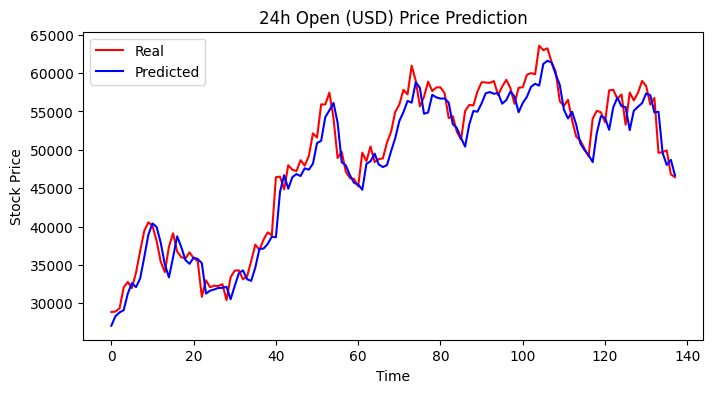

In [128]:
feature_names = ['24h Open (USD)']

for i in range(predicted_stock_price.shape[1]):
    plt.figure(figsize=(8, 4))

    plt.plot(test_dataset[:, i], color='red', label='Real')
    plt.plot(predicted_stock_price[:, i], color='blue', label='Predicted')

    plt.title(f'{feature_names[i]} Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()

    plt.show()

## Evaluation Metrics

In [129]:
feature_names = ['24h Open (USD)']

results = []

for i in range(predicted_stock_price.shape[1]):
    y_true = test_dataset[:, i]
    y_pred = predicted_stock_price[:, i]

    results.append({
        'Variable': feature_names[i],
        'MSE': metrics.mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(metrics.mean_squared_error(y_true, y_pred)),
        'MAE': metrics.mean_absolute_error(y_true, y_pred),
        'R2': metrics.r2_score(y_true, y_pred)
    })


df_results = pd.DataFrame(results)
df_results

,Variable,MSE,RMSE,MAE,R2
0,24h Open (USD),5.351130e+06,2313.250955,1807.327487,0.94417


## Future price prediction





In [130]:
data_test['Date'] = pd.to_datetime(data_test['Date'])


feature_names = ['24h Open (USD)']


def predict_future_stock_prices(model, last_known_data, num_future_steps):
    predictions = []
    current_input = last_known_data.copy()

    for _ in range(num_future_steps):
        pred = model.predict(current_input[np.newaxis, :, :], verbose=0)


        next_step = pred[0]

        current_input = np.vstack((current_input[1:], next_step))

        predictions.append(next_step)

    return np.array(predictions)


# Last 60 days from scaled input data
last_known_data = inputs[-30:]

# Number of future days
num_future_steps = 30

# Predict future scaled values
future_predictions = predict_future_stock_prices(
    final_model,
    last_known_data,
    num_future_steps
)

# Inverse scale predictions
future_predictions_inverse = sc.inverse_transform(future_predictions)

# Create future dates
last_date = data_test['Date'].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=num_future_steps
)

# Create future dataframe
future_df = pd.DataFrame(
    future_predictions_inverse,
    columns=feature_names
)

future_df['Date'] = future_dates
future_df = future_df[['Date'] + feature_names]

future_df

/tmp/ipykernel_2947/3161966832.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test['Date'] = pd.to_datetime(data_test['Date'])


,Date,24h Open (USD)
0,2021-05-19,45577.121094
1,2021-05-20,44866.726562
2,2021-05-21,44257.917969
3,2021-05-22,43681.300781
4,2021-05-23,43121.113281
5,2021-05-24,42572.468750
6,2021-05-25,42035.109375
7,2021-05-26,41508.667969
8,2021-05-27,40990.519531
9,2021-05-28,40481.042969


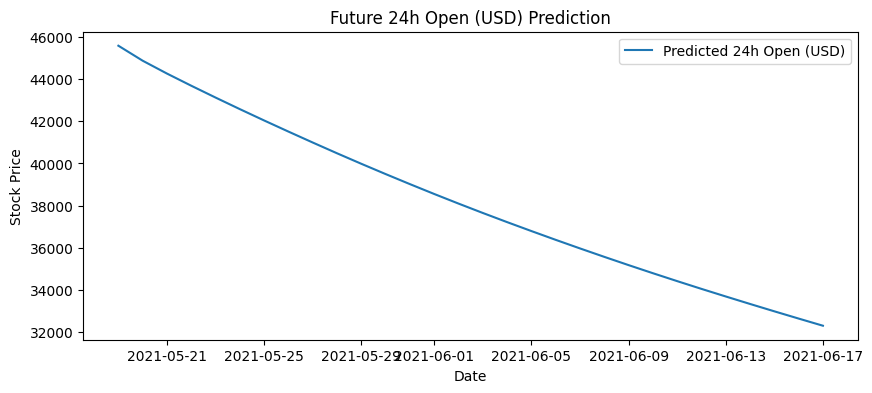

In [131]:
for col in feature_names:
    plt.figure(figsize=(10, 4))
    plt.plot(future_df['Date'], future_df[col], label=f'Predicted {col}')
    plt.title(f'Future {col} Prediction')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()